In [1]:
import torch
from torch import nn, Tensor
import torch.nn.functional as F

from typing import Any, Callable, List, Optional, Sequence, Tuple, Union
import math
from functools import partial

### Helper functions

In [2]:
class MLP(torch.nn.Sequential):
    """This block implements the multi-layer perceptron (MLP) module.

    Args:
        in_channels (int): Number of channels of the input
        hidden_channels (List[int]): List of the hidden channel dimensions
        norm_layer (Callable[..., torch.nn.Module], optional): Norm layer that will be stacked on top of the linear layer. If ``None`` this layer won't be used. Default: ``None``
        activation_layer (Callable[..., torch.nn.Module], optional): Activation function which will be stacked on top of the normalization layer (if not None), otherwise on top of the linear layer. If ``None`` this layer won't be used. Default: ``torch.nn.ReLU``
        inplace (bool, optional): Parameter for the activation layer, which can optionally do the operation in-place.
            Default is ``None``, which uses the respective default values of the ``activation_layer`` and Dropout layer.
        bias (bool): Whether to use bias in the linear layer. Default ``True``
        dropout (float): The probability for the dropout layer. Default: 0.0
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: List[int],
        norm_layer: Optional[Callable[..., torch.nn.Module]] = None,
        activation_layer: Optional[Callable[..., torch.nn.Module]] = torch.nn.ReLU,
        inplace: Optional[bool] = None,
        bias: bool = True,
        dropout: float = 0.0,
    ):
        params = {} if inplace is None else {"inplace": inplace}

        layers = []
        in_dim = in_channels
        for hidden_dim in hidden_channels[:-1]:
            layers.append(torch.nn.Linear(in_dim, hidden_dim, bias=bias))
            if norm_layer is not None:
                layers.append(norm_layer(hidden_dim))
            layers.append(activation_layer(**params))
            layers.append(torch.nn.Dropout(dropout, **params))
            in_dim = hidden_dim

        layers.append(torch.nn.Linear(in_dim, hidden_channels[-1], bias=bias))
        layers.append(torch.nn.Dropout(dropout, **params))

        super().__init__(*layers)


class Permute(torch.nn.Module):
    """This module returns a view of the tensor input with its dimensions permuted.

    Args:
        dims (List[int]): The desired ordering of dimensions
    """

    def __init__(self, dims: List[int]):
        super().__init__()
        self.dims = dims

    def forward(self, x: Tensor) -> Tensor:
        return torch.permute(x, self.dims)


def stochastic_depth(input: Tensor, p: float, mode: str, training: bool = True) -> Tensor:
    """
    Implements the Stochastic Depth from `"Deep Networks with Stochastic Depth"
    <https://arxiv.org/abs/1603.09382>`_ used for randomly dropping residual
    branches of residual architectures.

    Args:
        input (Tensor[N, ...]): The input tensor or arbitrary dimensions with the first one
                    being its batch i.e. a batch with ``N`` rows.
        p (float): probability of the input to be zeroed.
        mode (str): ``"batch"`` or ``"row"``.
                    ``"batch"`` randomly zeroes the entire input, ``"row"`` zeroes
                    randomly selected rows from the batch.
        training: apply stochastic depth if is ``True``. Default: ``True``

    Returns:
        Tensor[N, ...]: The randomly zeroed tensor.
    """
    if p < 0.0 or p > 1.0:
        raise ValueError(f"drop probability has to be between 0 and 1, but got {p}")
    if mode not in ["batch", "row"]:
        raise ValueError(f"mode has to be either 'batch' or 'row', but got {mode}")
    if not training or p == 0.0:
        return input

    survival_rate = 1.0 - p
    if mode == "row":
        size = [input.shape[0]] + [1] * (input.ndim - 1)
    else:
        size = [1] * input.ndim
    noise = torch.empty(size, dtype=input.dtype, device=input.device)
    noise = noise.bernoulli_(survival_rate)
    if survival_rate > 0.0:
        noise.div_(survival_rate)
    return input * noise


class StochasticDepth(nn.Module):
    """
    See :func:`stochastic_depth`.
    """

    def __init__(self, p: float, mode: str) -> None:
        super().__init__()
        self.p = p
        self.mode = mode

    def forward(self, input: Tensor) -> Tensor:
        return stochastic_depth(input, self.p, self.mode, self.training)

    def __repr__(self) -> str:
        s = f"{self.__class__.__name__}(p={self.p}, mode={self.mode})"
        return s

### Patch Merging

In [3]:
def _patch_merging_data(x: torch.Tensor) -> torch.Tensor:
    """
    Patch merging for data tensor with circular padding on x-axis and zero padding on y-axis.

    Args:
        x: Input data tensor with shape (..., H, W, C).

    Returns:
        torch.Tensor: Merged tensor with shape (..., H/2, W/2, 4*C).
    """
    H, W, _ = x.shape[-3:]

    # Circular padding for x-axis (width)
    x = F.pad(x, (0, 0, W % 2, 0), mode='circular')

    # Zero padding for y-axis (height)
    x = F.pad(x, (0, 0, 0, 0, 0, H % 2))

    # Patch merging
    x0 = x[..., 0::2, 0::2, :]  # Top-left pixels
    x1 = x[..., 1::2, 0::2, :]  # Bottom-left pixels
    x2 = x[..., 0::2, 1::2, :]  # Top-right pixels
    x3 = x[..., 1::2, 1::2, :]  # Bottom-right pixels
    x = torch.cat([x0, x1, x2, x3], dim=-1)  # Concatenate along channel dimension

    return x

def _patch_merging_mask(mask: torch.Tensor) -> torch.Tensor:
    """
    Patch merging for boolean mask with circular padding on x-axis and zero padding on y-axis.

    Args:
        mask: Input mask tensor with shape (..., H, W).

    Returns:
        torch.Tensor: Merged mask tensor with shape (..., H/2, W/2).
    """
    H, W = mask.shape[-2:]

    # Circular padding for x-axis (width)
    mask = F.pad(mask.float(), (0, W % 2), mode='circular').bool()

    # Zero padding for y-axis (height)
    mask = F.pad(mask.float(), (0, 0, 0, H % 2), value=0).bool()

    # Patch merging
    m0 = mask[..., 0::2, 0::2]  # Top-left
    m1 = mask[..., 1::2, 0::2]  # Bottom-left
    m2 = mask[..., 0::2, 1::2]  # Top-right
    m3 = mask[..., 1::2, 1::2]  # Bottom-right
    mask = (m0 & m1 & m2 & m3)  # Logical OR for mask merging

    return mask

In [4]:
class PatchMerging(nn.Module):
    """Patch Merging Layer.
    Args:
        dim (int): Number of input channels.
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
    """

    def __init__(self, dim: int, norm_layer: Callable[..., nn.Module] = nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x: Tensor):
        """
        Args:
            x (Tensor): input tensor with expected layout of [..., H, W, C]
        Returns:
            Tensor with layout of [..., H/2, W/2, 2*C]
        """
        x = _patch_merging_data(x)
        x = self.norm(x)
        x = self.reduction(x)  # ... H/2 W/2 2*C
        return x


class PatchMergingV2(nn.Module):
    """Patch Merging Layer for Swin Transformer V2.
    Args:
        dim (int): Number of input channels.
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
    """

    def __init__(self, dim: int, norm_layer: Callable[..., nn.Module] = nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(2 * dim)  # difference

    def forward(self, x: Tensor):
        """
        Args:
            x (Tensor): input tensor with expected layout of [..., H, W, C]
        Returns:
            Tensor with layout of [..., H/2, W/2, 2*C]
        """
        x = _patch_merging_data(x)
        x = self.reduction(x)  # ... H/2 W/2 2*C
        x = self.norm(x)
        return x

### Shifted Window Attention

In [5]:
def shifted_window_attention(
    input: Tensor,
    qkv_weight: Tensor,
    proj_weight: Tensor,
    window_size: List[int],
    num_heads: int,
    shift_size: List[int],
    attention_dropout: float = 0.0,
    dropout: float = 0.0,
    qkv_bias: Optional[Tensor] = None,
    proj_bias: Optional[Tensor] = None,
    logit_scale: Optional[torch.Tensor] = None,
    land_mask: Tensor = None,
    training: bool = True,
) -> Tensor:
    """
    Window based multi-head self attention (W-MSA) module.
    It supports both of shifted and non-shifted window.
    Args:
        input (Tensor[N, H, W, C]): The input tensor or 4-dimensions.
        qkv_weight (Tensor[in_dim, out_dim]): The weight tensor of query, key, value.
        proj_weight (Tensor[out_dim, out_dim]): The weight tensor of projection.
        window_size (List[int]): Window size.
        num_heads (int): Number of attention heads.
        shift_size (List[int]): Shift size for shifted window attention.
        attention_dropout (float): Dropout ratio of attention weight. Default: 0.0.
        dropout (float): Dropout ratio of output. Default: 0.0.
        qkv_bias (Tensor[out_dim], optional): The bias tensor of query, key, value. Default: None.
        proj_bias (Tensor[out_dim], optional): The bias tensor of projection. Default: None.
        logit_scale (Tensor[out_dim], optional): Logit scale of cosine attention for Swin Transformer V2. Default: None.
        training (bool, optional): Training flag used by the dropout parameters. Default: True.
    Returns:
        Tensor[N, H, W, C]: The output tensor after shifted window attention.
    """
    B, H, W, C = input.shape
    print("Input shape : ", input.shape)
    # pad feature maps to multiples of window size
    pad_r = (window_size[1] - W % window_size[1]) % window_size[1]
    pad_b = (window_size[0] - H % window_size[0]) % window_size[0]
    x = F.pad(input, (0, 0, pad_r, 0), mode='circular')
    x = F.pad(x, (0, 0, 0, 0, 0, pad_b))
    print("Input padded shape : ", x.shape)
    _, pad_H, pad_W, _ = x.shape

    shift_size = shift_size.copy()
    # If window size is larger than feature size, there is no need to shift window
    if window_size[0] >= pad_H:
        shift_size[0] = 0
    if window_size[1] >= pad_W:
        shift_size[1] = 0

    # cyclic shift
    if sum(shift_size) > 0:
        x = torch.roll(x, shifts=(-shift_size[0], -shift_size[1]), dims=(1, 2))

    # partition windows
    num_windows = (pad_H // window_size[0]) * (pad_W // window_size[1])
    x = x.view(B, pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1], C)
    print("x shape after partition: ", x.shape)
    x = x.permute(0, 1, 3, 2, 4, 5).reshape(B * num_windows, window_size[0] * window_size[1], C)  # B*nW, Ws*Ws, C
    print("x shape after permute: ", x.shape)

    # multi-head attention
    if logit_scale is not None and qkv_bias is not None:
        qkv_bias = qkv_bias.clone()
        length = qkv_bias.numel() // 3
        qkv_bias[length : 2 * length].zero_()
    qkv = F.linear(x, qkv_weight, qkv_bias)
    print("qkv shape: ", qkv.shape)
    qkv = qkv.reshape(x.size(0), x.size(1), 3, num_heads, C // num_heads).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]
    print("q shape: ", q.shape)
    if logit_scale is not None:
        # cosine attention
        attn = F.normalize(q, dim=-1) @ F.normalize(k, dim=-1).transpose(-2, -1)
        logit_scale = torch.clamp(logit_scale, max=math.log(100.0)).exp()
        attn = attn * logit_scale
    else:
        q = q * (C // num_heads) ** -0.5
        attn = q.matmul(k.transpose(-2, -1))
    print("attn:", attn.shape)
    print()
    # add land mask
    # land_attn_mask = land_mask.masked_fill(land_mask, float(-100.0)).masked_fill(~land_mask, float(0.0))
    # print(land_attn_mask.shape)
    # print(attn.shape)
    # attn = attn + land_attn_mask

    if sum(shift_size) > 0:
        # generate attention mask
        attn_mask = x.new_zeros((pad_H, pad_W))
        h_slices = ((0, -window_size[0]), (-window_size[0], -shift_size[0]), (-shift_size[0], None))
        w_slices = ((0, -window_size[1]), (-window_size[1], -shift_size[1]), (-shift_size[1], None))
        count = 0
        for h in h_slices:
            for w in w_slices:
                attn_mask[h[0] : h[1], w[0] : w[1]] = count
                count += 1
        attn_mask = attn_mask.view(pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1])
        attn_mask = attn_mask.permute(0, 2, 1, 3).reshape(num_windows, window_size[0] * window_size[1])
        attn_mask = attn_mask.unsqueeze(1) - attn_mask.unsqueeze(2)
        attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        attn = attn.view(x.size(0) // num_windows, num_windows, num_heads, x.size(1), x.size(1))
        attn = attn + attn_mask.unsqueeze(1).unsqueeze(0)
        attn = attn.view(-1, num_heads, x.size(1), x.size(1))

    attn = F.softmax(attn, dim=-1)
    attn = F.dropout(attn, p=attention_dropout, training=training)

    x = attn.matmul(v).transpose(1, 2).reshape(x.size(0), x.size(1), C)
    x = F.linear(x, proj_weight, proj_bias)
    x = F.dropout(x, p=dropout, training=training)

    # reverse windows
    x = x.view(B, pad_H // window_size[0], pad_W // window_size[1], window_size[0], window_size[1], C)
    x = x.permute(0, 1, 3, 2, 4, 5).reshape(B, pad_H, pad_W, C)

    # reverse cyclic shift
    if sum(shift_size) > 0:
        x = torch.roll(x, shifts=(shift_size[0], shift_size[1]), dims=(1, 2))

    # unpad features
    x = x[:, :H, :W, :].contiguous()
    return x


class ShiftedWindowAttention(nn.Module):
    """
    See :func:`shifted_window_attention`.
    """

    def __init__(
        self,
        dim: int,
        window_size: List[int],
        shift_size: List[int],
        num_heads: int,
        land_mask: Tensor,
        qkv_bias: bool = True,
        proj_bias: bool = True,
        attention_dropout: float = 0.0,
        dropout: float = 0.0,
    ):
        super().__init__()
        if len(window_size) != 2 or len(shift_size) != 2:
            raise ValueError("window_size and shift_size must be of length 2")
        self.window_size = window_size
        self.shift_size = shift_size
        self.num_heads = num_heads
        self.attention_dropout = attention_dropout
        self.dropout = dropout
        self.land_mask = land_mask

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim, bias=proj_bias)

    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x (Tensor): Tensor with layout of [B, H, W, C]
        Returns:
            Tensor with same layout as input, i.e. [B, H, W, C]
        """
        return shifted_window_attention(
            x,
            self.qkv.weight,
            self.proj.weight,
            self.window_size,
            self.num_heads,
            shift_size=self.shift_size,
            attention_dropout=self.attention_dropout,
            dropout=self.dropout,
            qkv_bias=self.qkv.bias,
            proj_bias=self.proj.bias,
            land_mask=self.land_mask,
            training=self.training,
        )


class ShiftedWindowAttentionV2(ShiftedWindowAttention):
    """
    See :func:`shifted_window_attention_v2`.
    """

    def __init__(
        self,
        dim: int,
        window_size: List[int],
        shift_size: List[int],
        num_heads: int,
        land_mask: Tensor,
        qkv_bias: bool = True,
        proj_bias: bool = True,
        attention_dropout: float = 0.0,
        dropout: float = 0.0,
    ):
        super().__init__(
            dim,
            window_size,
            shift_size,
            num_heads,
            land_mask,
            qkv_bias=qkv_bias,
            proj_bias=proj_bias,
            attention_dropout=attention_dropout,
            dropout=dropout,
        )

        self.logit_scale = nn.Parameter(torch.log(10 * torch.ones((num_heads, 1, 1))))
        self.land_mask = land_mask
        if qkv_bias:
            length = self.qkv.bias.numel() // 3
            self.qkv.bias[length : 2 * length].data.zero_()

    def forward(self, x: Tensor):
        """
        Args:
            x (Tensor): Tensor with layout of [B, H, W, C]
        Returns:
            Tensor with same layout as input, i.e. [B, H, W, C]
        """
        return shifted_window_attention(
            x,
            self.qkv.weight,
            self.proj.weight,
            self.window_size,
            self.num_heads,
            shift_size=self.shift_size,
            attention_dropout=self.attention_dropout,
            dropout=self.dropout,
            qkv_bias=self.qkv.bias,
            proj_bias=self.proj.bias,
            logit_scale=self.logit_scale,
            land_mask=self.land_mask,
            training=self.training,
        )

### Swin Transformer

In [6]:

class SwinTransformerBlock(nn.Module):
    """
    Swin Transformer Block.
    Args:
        dim (int): Number of input channels.
        num_heads (int): Number of attention heads.
        window_size (List[int]): Window size.
        shift_size (List[int]): Shift size for shifted window attention.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4.0.
        dropout (float): Dropout rate. Default: 0.0.
        attention_dropout (float): Attention dropout rate. Default: 0.0.
        stochastic_depth_prob: (float): Stochastic depth rate. Default: 0.0.
        norm_layer (nn.Module): Normalization layer.  Default: nn.LayerNorm.
        attn_layer (nn.Module): Attention layer. Default: ShiftedWindowAttention
    """

    def __init__(
        self,
        dim: int,
        num_heads: int,
        window_size: List[int],
        shift_size: List[int],
        land_mask: Tensor,
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
        attention_dropout: float = 0.0,
        stochastic_depth_prob: float = 0.0,
        norm_layer: Callable[..., nn.Module] = nn.LayerNorm,
        attn_layer: Callable[..., nn.Module] = ShiftedWindowAttention,
    ):
        super().__init__()

        self.norm1 = norm_layer(dim)
        self.attn = attn_layer(
            dim,
            window_size,
            shift_size,
            num_heads,
            attention_dropout=attention_dropout,
            dropout=dropout,
            land_mask=land_mask
        )
        self.stochastic_depth = StochasticDepth(stochastic_depth_prob, "row")
        self.norm2 = norm_layer(dim)
        self.mlp = MLP(dim, [int(dim * mlp_ratio), dim], activation_layer=nn.GELU, inplace=None, dropout=dropout)

        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.normal_(m.bias, std=1e-6)

    def forward(self, x: Tensor):
        x = x + self.stochastic_depth(self.attn(self.norm1(x)))
        x = x + self.stochastic_depth(self.mlp(self.norm2(x)))
        return x


class SwinTransformerBlockV2(SwinTransformerBlock):
    """
    Swin Transformer V2 Block.
    Args:
        dim (int): Number of input channels.
        num_heads (int): Number of attention heads.
        window_size (List[int]): Window size.
        shift_size (List[int]): Shift size for shifted window attention.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4.0.
        dropout (float): Dropout rate. Default: 0.0.
        attention_dropout (float): Attention dropout rate. Default: 0.0.
        stochastic_depth_prob: (float): Stochastic depth rate. Default: 0.0.
        norm_layer (nn.Module): Normalization layer.  Default: nn.LayerNorm.
        attn_layer (nn.Module): Attention layer. Default: ShiftedWindowAttentionV2.
    """

    def __init__(
        self,
        dim: int,
        num_heads: int,
        window_size: List[int],
        shift_size: List[int],
        land_mask: Tensor,
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
        attention_dropout: float = 0.0,
        stochastic_depth_prob: float = 0.0,
        norm_layer: Callable[..., nn.Module] = nn.LayerNorm,
        attn_layer: Callable[..., nn.Module] = ShiftedWindowAttentionV2,
    ):
        super().__init__(
            dim,
            num_heads,
            window_size,
            shift_size,
            land_mask,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
            attention_dropout=attention_dropout,
            stochastic_depth_prob=stochastic_depth_prob,
            norm_layer=norm_layer,
            attn_layer=attn_layer,
        )

    def forward(self, x: Tensor):
        # Here is the difference, we apply norm after the attention in V2.
        # In V1 we applied norm before the attention.
        x = x + self.stochastic_depth(self.norm1(self.attn(x)))
        x = x + self.stochastic_depth(self.norm2(self.mlp(x)))
        return x


class SwinTransformer(nn.Module):
    """
    Implements Swin Transformer from the `"Swin Transformer: Hierarchical Vision Transformer using
    Shifted Windows" <https://arxiv.org/abs/2103.14030>`_ paper.
    Args:
        patch_size (List[int]): Patch size.
        embed_dim (int): Patch embedding dimension.
        depths (List(int)): Depth of each Swin Transformer layer.
        num_heads (List(int)): Number of attention heads in different layers.
        window_size (List[int]): Window size.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4.0.
        dropout (float): Dropout rate. Default: 0.0.
        attention_dropout (float): Attention dropout rate. Default: 0.0.
        stochastic_depth_prob (float): Stochastic depth rate. Default: 0.1.
        block (nn.Module, optional): SwinTransformer Block. Default: None.
        norm_layer (nn.Module, optional): Normalization layer. Default: None.
        downsample_layer (nn.Module): Downsample layer (patch merging). Default: PatchMerging.
    """

    def __init__(
        self,
        in_channels: int,
        patch_size: List[int],
        embed_dim: int,
        depths: List[int],
        num_heads: List[int],
        window_size: List[int],
        lat: Tensor, 
        lon: Tensor,
        land_mask: Tensor,
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
        attention_dropout: float = 0.0,
        stochastic_depth_prob: float = 0.1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
        block: Optional[Callable[..., nn.Module]] = None,
        downsample_layer: Callable[..., nn.Module] = PatchMerging,
    ):
        super().__init__()

        if block is None:
            block = SwinTransformerBlock
        if norm_layer is None:
            norm_layer = partial(nn.LayerNorm, eps=1e-5)
            
        # split image into non-overlapping patches
        self.patchify = nn.Conv2d(
                    in_channels, embed_dim, kernel_size=(patch_size[0], patch_size[1]), stride=(patch_size[0], patch_size[1])
                )
        
        self.norm1 = nn.Sequential(
                Permute([0, 2, 3, 1]),
                norm_layer(embed_dim),
            )

        layers: List[nn.Module] = []

        total_stage_blocks = sum(depths)
        stage_block_id = 0
        # build SwinTransformer blocks
        for i_stage in range(len(depths)):
            stage: List[nn.Module] = []
            dim = embed_dim * 2**i_stage
            for i_layer in range(depths[i_stage]):
                # adjust stochastic depth probability based on the depth of the stage block
                sd_prob = stochastic_depth_prob * float(stage_block_id) / (total_stage_blocks - 1)
                stage.append(
                    block(
                        dim,
                        num_heads[i_stage],
                        window_size=window_size,
                        shift_size=[0 if i_layer % 2 == 0 else w // 2 for w in window_size],
                        land_mask=land_mask,
                        mlp_ratio=mlp_ratio,
                        dropout=dropout,
                        attention_dropout=attention_dropout,
                        stochastic_depth_prob=sd_prob,
                        norm_layer=norm_layer,
                    )
                )
                stage_block_id += 1
            layers.append(nn.Sequential(*stage))
            # add patch merging layer
            if i_stage < (len(depths) - 1):
                layers.append(downsample_layer(dim, norm_layer))
        self.features = nn.Sequential(*layers)
        self.embed_dim = embed_dim
        self.patch_size = patch_size

        num_features = embed_dim * 2 ** (len(depths) - 1)
        self.norm = norm_layer(num_features)
        self.permute = Permute([0, 3, 1, 2])  # B H W C -> B C H W

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
                    
        self.lat = lat
        self.lon = lon
    
    def _fourier_pos_encoding(self) -> Tensor:
        """
        Args
            x: C x H x W. first two channels are lat, and lon
        Returns
            Tensor: Tensor of shape B x E x H x W where E is the embedding
                dimension.
        """

        # B x C x H x W -> B x 1 x H/P x W/P
        latitudes_patch = F.avg_pool2d(
            self.lat,
            kernel_size=self.patch_size,
            stride=self.patch_size,
        )
        longitudes_patch = F.avg_pool2d(
            self.lon,
            kernel_size=self.patch_size,
            stride=self.patch_size,
        )

        modes = (
            torch.arange(self.embed_dim // 4, device=lat.device).view(
                1, -1, 1, 1
            )
            + 1.0
        )
        pos_encoding = torch.cat(
            (
                torch.sin(latitudes_patch * modes),
                torch.sin(longitudes_patch * modes),
                torch.cos(latitudes_patch * modes),
                torch.cos(longitudes_patch * modes),
            ),
            axis=1,
        )

        return pos_encoding

    def forward(self, x):
        x = self.patchify(x)
        x = x + self._fourier_pos_encoding() # Absolute fourier positional encoding
        x = self.norm1(x)
        x = self.features(x)
        x = self.norm(x)
        x = self.permute(x)
        return x

### Data

In [12]:
# Data

import xarray as xr
import torch
import sys
import os

sys.path.append("../../src")
from constants import INPT_VARS, EXTRA_VARS, OUT_VARS
from utils.train_utils import extract_wet, extract_surface_wet
from utils.data_utils import data_CNN_Disk

data_dir = "/pscratch/sd/s/suryad/data"
wet_file = "OM4_5daily_v0.2.1_wetmask"
surface_wet_file = "surface_wet.pt"
data_zarr = "3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975"
data_means_zarr = "3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_means"
data_stds_zarr = "3D_data_OM4_5daily_v0.2.1_with_hfds_anom_1975_stds"
grid_file = "Grid_New.nc"

inputs = INPT_VARS["3D_noFast_all"]
extra_in = EXTRA_VARS["3D_all_hfds_anom"]
outputs = OUT_VARS["3D_noFast_all"]
lag = 1
interval = 1
hist = 1
N_samples = 20
N_val = 10
steps = 4

s_train = lag * hist
e_train = s_train + N_samples * interval
e_test = e_train + interval * N_val


data = xr.open_zarr(os.path.join(data_dir, data_zarr))
data_mean = xr.open_zarr(os.path.join(data_dir, data_means_zarr))
data_std = xr.open_zarr(os.path.join(data_dir, data_stds_zarr))

wet_zarr = xr.open_zarr(os.path.join(data_dir, wet_file))
wet = extract_wet(wet_zarr, outputs, hist)
surface_wet = extract_surface_wet(wet_zarr)

val_data = data_CNN_Disk(
    data,
    inputs,
    extra_in,
    outputs,
    wet,
    data_mean,
    data_std,
    N_val,
    lag,
    interval,
    hist,
    e_train,
    long_rollout=True,
    device="cuda",
)

lat = torch.tensor(data.lat.values).to(dtype=torch.float32).unsqueeze(0).cuda()
lon = torch.tensor(data.lon.values).to(dtype=torch.float32).unsqueeze(0).cuda()
mask = ~torch.tensor(data.wetmask.isel(lev=0).values).cuda()


torch.Size([78, 180, 360])
Long rollout will begin with input and produce output from time index 21 and 23 respectively


/pscratch/sd/s/suryad/conda_envs/emulator_scratch/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:188: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


### Model

In [13]:
d = val_data[0]
d[0].shape

torch.Size([1, 82, 180, 360])

In [14]:
from torchinfo import summary

In [15]:
ST = SwinTransformer(
    in_channels=d[0].shape[1],
    patch_size=[2, 2],
    embed_dim=216,
    depths=[2, 2, 6, 2],
    num_heads=[3, 6, 12, 24],
    window_size=[8, 8],
    lat=lat,
    lon=lon,
    land_mask=mask,
    stochastic_depth_prob=0.2,
    # block=SwinTransformerBlockV2,
    # downsample_layer=PatchMergingV2,
).cuda()

In [16]:
ST(d[0].cuda())

Input shape :  torch.Size([1, 90, 180, 216])
Input padded shape :  torch.Size([1, 96, 184, 216])
x shape after partition:  torch.Size([1, 12, 8, 23, 8, 216])
x shape after permute:  torch.Size([276, 64, 216])
qkv shape:  torch.Size([276, 64, 648])
q shape:  torch.Size([276, 3, 64, 72])
attn: torch.Size([276, 3, 64, 64])

Input shape :  torch.Size([1, 90, 180, 216])
Input padded shape :  torch.Size([1, 96, 184, 216])
x shape after partition:  torch.Size([1, 12, 8, 23, 8, 216])
x shape after permute:  torch.Size([276, 64, 216])
qkv shape:  torch.Size([276, 64, 648])
q shape:  torch.Size([276, 3, 64, 72])
attn: torch.Size([276, 3, 64, 64])

Input shape :  torch.Size([1, 45, 90, 432])
Input padded shape :  torch.Size([1, 48, 96, 432])
x shape after partition:  torch.Size([1, 6, 8, 12, 8, 432])
x shape after permute:  torch.Size([72, 64, 432])
qkv shape:  torch.Size([72, 64, 1296])
q shape:  torch.Size([72, 6, 64, 72])
attn: torch.Size([72, 6, 64, 64])

Input shape :  torch.Size([1, 45, 90,

tensor([[[[ 2.0764e+00,  1.2290e+00,  1.2022e+00,  ...,  1.9127e+00,
            5.4973e-01,  2.7077e+00],
          [ 7.5894e-01,  4.2804e-01, -6.2923e-01,  ...,  8.3324e-01,
           -1.5089e-01,  2.0517e+00],
          [ 3.4096e-01, -4.1872e-01, -4.6757e-01,  ...,  1.7337e-01,
           -1.1646e+00,  1.1619e+00],
          ...,
          [ 1.6409e-01, -3.1074e-01,  8.0652e-01,  ...,  1.4915e-01,
           -1.1651e+00,  9.3215e-01],
          [ 7.9199e-01,  1.6291e+00,  7.9620e-01,  ...,  8.1851e-01,
            1.8229e-03,  1.9455e+00],
          [ 2.7304e-01,  7.1738e-01,  8.5681e-01,  ...,  1.7636e+00,
            7.4208e-01,  1.7909e+00]],

         [[ 2.4354e-02,  2.8698e+00,  1.1627e+00,  ...,  8.4899e-01,
            8.0483e-01,  1.0665e+00],
          [-4.1549e-01,  1.0685e+00,  2.8053e-01,  ..., -3.2205e-01,
           -3.1220e-01,  2.6471e-01],
          [-1.0389e-01,  1.9839e+00,  8.7127e-01,  ...,  8.8990e-03,
            9.9323e-01,  4.3935e-01],
          ...,
     

#### Notes

1. I need to ensure the land mask is the same size as attn. I presume it would go through the same transformations as the original input.

Something to think about: Do I just need to mask out the first attention and then assume no land remains in the representation thereafter?

---

Input shape :  torch.Size([1, 90, 180, 216])

Input padded shape :  torch.Size([1, 96, 184, 216])

x shape after partition:  torch.Size([1, 12, 8, 23, 8, 216])

x shape after permute:  torch.Size([276, 64, 216])

qkv shape:  torch.Size([276, 64, 648])

q shape:  torch.Size([276, 3, 64, 72])

attn: torch.Size([276, 3, 64, 64])


---

mask shape: ([90, 180])

padded mask shape: ([96, 184])

partitioned mask: ([12, 8, 23, 8])

permuted mask: ([276, 64])

add axis for heads: ([276, 1, 64])

In [135]:
summary(ST, input_data=d[0].cuda(), col_names=['input_size','output_size'])

Layer (type:depth-idx)                             Input Shape               Output Shape
SwinTransformer                                    [1, 82, 180, 360]         [1, 1728, 12, 23]
├─Conv2d: 1-1                                      [1, 82, 180, 360]         [1, 216, 90, 180]
├─Sequential: 1-2                                  [1, 216, 90, 180]         [1, 90, 180, 216]
│    └─Permute: 2-1                                [1, 216, 90, 180]         [1, 90, 180, 216]
│    └─LayerNorm: 2-2                              [1, 90, 180, 216]         [1, 90, 180, 216]
├─Sequential: 1-3                                  [1, 90, 180, 216]         [1, 12, 23, 1728]
│    └─Sequential: 2-3                             [1, 90, 180, 216]         [1, 90, 180, 216]
│    │    └─SwinTransformerBlock: 3-1              [1, 90, 180, 216]         [1, 90, 180, 216]
│    │    └─SwinTransformerBlock: 3-2              [1, 90, 180, 216]         [1, 90, 180, 216]
│    └─PatchMerging: 2-4                           [1, 

### Cyclic Shifts

In [30]:
input = torch.ones([1, 90, 180, 216])
window_size = [8,8]
shift_size = [0 for w in window_size]
# shift_size = [w // 2 for w in window_size]
qkv = nn.Linear(216, 216 * 3, bias=False)
proj = nn.Linear(216, 216, bias=False)
qkv_weight = qkv.weight
qkv_bias = qkv.bias
proj_weight = proj.weight
proj_bias = proj.bias
num_heads=6
attention_dropout=0.1
dropout=0.1
training=True

In [50]:
x = torch.arange(25).reshape([1, 5, 5, 1])
window_size = [3,3]
B, H, W, C = x.shape
pad_r = (window_size[1] - W % window_size[1]) % window_size[1]
pad_b = (window_size[0] - H % window_size[0]) % window_size[0]
x = F.pad(x, (0, 0, pad_r, 0), mode='circular')
x = F.pad(x, (0, 0, 0, 0, 0, pad_b))
_, pad_H, pad_W, _ = x.shape
shift_size = [2,2]
print(x.view([1,1,6,6]))
x = torch.roll(x, shifts=(-shift_size[0], -shift_size[1]), dims=(1, 2))
print(x.view([1,1,6,6]))

tensor([[[[ 4,  0,  1,  2,  3,  4],
          [ 9,  5,  6,  7,  8,  9],
          [14, 10, 11, 12, 13, 14],
          [19, 15, 16, 17, 18, 19],
          [24, 20, 21, 22, 23, 24],
          [ 0,  0,  0,  0,  0,  0]]]])
tensor([[[[11, 12, 13, 14, 14, 10],
          [16, 17, 18, 19, 19, 15],
          [21, 22, 23, 24, 24, 20],
          [ 0,  0,  0,  0,  0,  0],
          [ 1,  2,  3,  4,  4,  0],
          [ 6,  7,  8,  9,  9,  5]]]])


In [62]:
attn = torch.ones([1, 1, 9, 9])
attn_mask = x.new_zeros((pad_H, pad_W))
print(attn_mask.shape)
h_slices = ((0, -window_size[0]), (-window_size[0], -shift_size[0]), (-shift_size[0], None))
w_slices = ((0, -window_size[1]), (-window_size[1], -shift_size[1]), (-shift_size[1], None))
count = 0
for h in h_slices:
    for w in w_slices:
        attn_mask[h[0] : h[1], w[0] : w[1]] = count
        count += 1
print(attn_mask)
num_windows = (pad_H // window_size[0]) * (pad_W // window_size[1])
attn_mask = attn_mask.view(pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1])
attn_mask = attn_mask.permute(0, 2, 1, 3).reshape(num_windows, window_size[0] * window_size[1])
attn_mask = attn_mask.unsqueeze(1) - attn_mask.unsqueeze(2)
attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
attn_mask.unsqueeze(1).unsqueeze(0).shape # number of heads and batch size

torch.Size([6, 6])
tensor([[0, 0, 0, 1, 2, 2],
        [0, 0, 0, 1, 2, 2],
        [0, 0, 0, 1, 2, 2],
        [3, 3, 3, 4, 5, 5],
        [6, 6, 6, 7, 8, 8],
        [6, 6, 6, 7, 8, 8]])


torch.Size([1, 4, 1, 9, 9])

In [33]:
B, H, W, C = input.shape
print("Input shape : ", input.shape)
# pad feature maps to multiples of window size
pad_r = (window_size[1] - W % window_size[1]) % window_size[1]
pad_b = (window_size[0] - H % window_size[0]) % window_size[0]
x = F.pad(input, (0, 0, pad_r, 0), mode='circular')
x = F.pad(x, (0, 0, 0, 0, 0, pad_b))
print("Input padded shape : ", x.shape)
_, pad_H, pad_W, _ = x.shape
print(pad_H, pad_W)

shift_size = shift_size.copy()
# If window size is larger than feature size, there is no need to shift window
if window_size[0] >= pad_H:
    shift_size[0] = 0
if window_size[1] >= pad_W:
    shift_size[1] = 0

# cyclic shift
if sum(shift_size) > 0:
    x = torch.roll(x, shifts=(-shift_size[0], -shift_size[1]), dims=(1, 2))

# partition windows
num_windows = (pad_H // window_size[0]) * (pad_W // window_size[1])
x = x.view(B, pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1], C)
print("x shape after partition: ", x.shape)
x = x.permute(0, 1, 3, 2, 4, 5).reshape(B * num_windows, window_size[0] * window_size[1], C)  # B*nW, Ws*Ws, C
print("x shape after permute: ", x.shape)

# multi-head attention
qkv = F.linear(x, qkv_weight, qkv_bias)
print("qkv shape: ", qkv.shape)
qkv = qkv.reshape(x.size(0), x.size(1), 3, num_heads, C // num_heads).permute(2, 0, 3, 1, 4)
q, k, v = qkv[0], qkv[1], qkv[2]
print("q shape: ", q.shape)
q = q * (C // num_heads) ** -0.5
attn = q.matmul(k.transpose(-2, -1))
print("attn:", attn.shape)
print()

if sum(shift_size) > 0:
    # generate attention mask
    attn_mask = x.new_zeros((pad_H, pad_W))
    h_slices = ((0, -window_size[0]), (-window_size[0], -shift_size[0]), (-shift_size[0], None))
    w_slices = ((0, -window_size[1]), (-window_size[1], -shift_size[1]), (-shift_size[1], None))
    count = 0
    for h in h_slices:
        for w in w_slices:
            attn_mask[h[0] : h[1], w[0] : w[1]] = count
            count += 1
    attn_mask = attn_mask.view(pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1])
    attn_mask = attn_mask.permute(0, 2, 1, 3).reshape(num_windows, window_size[0] * window_size[1])
    attn_mask = attn_mask.unsqueeze(1) - attn_mask.unsqueeze(2)
    attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
    attn = attn.view(x.size(0) // num_windows, num_windows, num_heads, x.size(1), x.size(1))
    attn = attn + attn_mask.unsqueeze(1).unsqueeze(0)
    attn = attn.view(-1, num_heads, x.size(1), x.size(1))

attn = F.softmax(attn, dim=-1)
attn = F.dropout(attn, p=attention_dropout, training=training)

x = attn.matmul(v).transpose(1, 2).reshape(x.size(0), x.size(1), C)
x = F.linear(x, proj_weight, proj_bias)
x = F.dropout(x, p=dropout, training=training)

# reverse windows
x = x.view(B, pad_H // window_size[0], pad_W // window_size[1], window_size[0], window_size[1], C)
x = x.permute(0, 1, 3, 2, 4, 5).reshape(B, pad_H, pad_W, C)

# reverse cyclic shift
if sum(shift_size) > 0:
    x = torch.roll(x, shifts=(shift_size[0], shift_size[1]), dims=(1, 2))

# unpad features
x = x[:, :H, :W, :].contiguous()
x

Input shape :  torch.Size([1, 90, 180, 216])
Input padded shape :  torch.Size([1, 96, 184, 216])
96 184
x shape after partition:  torch.Size([1, 12, 8, 23, 8, 216])
x shape after permute:  torch.Size([276, 64, 216])
qkv shape:  torch.Size([276, 64, 648])
q shape:  torch.Size([276, 6, 64, 36])
attn: torch.Size([276, 6, 64, 64])



tensor([[[[-0.2180,  0.2925, -0.0000,  ...,  0.0905,  0.6729,  0.3600],
          [-0.1994,  0.2964, -0.1200,  ...,  0.0000,  0.6981,  0.3667],
          [-0.2166,  0.3043, -0.1227,  ...,  0.0878,  0.6873,  0.3444],
          ...,
          [-0.0000,  0.0000, -0.1046,  ...,  0.0720,  0.6779,  0.3513],
          [-0.1946,  0.3148, -0.1053,  ...,  0.0814,  0.6842,  0.3707],
          [-0.2067,  0.3061, -0.1124,  ...,  0.0923,  0.7014,  0.3383]],

         [[-0.1798,  0.3119, -0.1134,  ...,  0.0827,  0.7113,  0.3567],
          [-0.2135,  0.3151, -0.1403,  ...,  0.0796,  0.6422,  0.3129],
          [-0.2014,  0.3116, -0.0000,  ...,  0.0770,  0.6691,  0.3548],
          ...,
          [-0.1991,  0.3065, -0.0984,  ...,  0.0831,  0.6594,  0.3672],
          [-0.0000,  0.2937, -0.1359,  ...,  0.1030,  0.7162,  0.3583],
          [-0.2125,  0.0000, -0.0000,  ...,  0.0856,  0.0000,  0.3598]],

         [[-0.1913,  0.3002, -0.1325,  ...,  0.0870,  0.6838,  0.3484],
          [-0.2024,  0.0000, -

### Channel-separable attention

Each module needs to be able to have fusion or no fusion

### Global Attention

### Complete Swin Encoder - ConvNext Decoder

### Masking

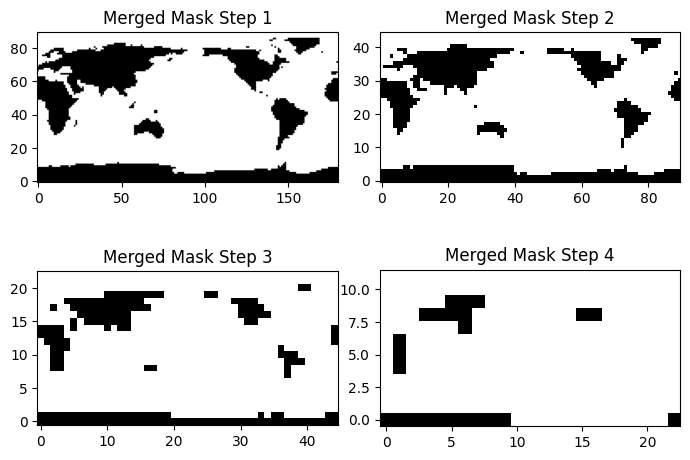

In [59]:
import matplotlib.pyplot as plt
import torch


def plot_successive_merged_masks(mask, num_steps=4):
    """
    Plots a grid of subplots showing successive additions of the merged mask.

    Args:
        mask: 2D binary tensor (H, W).
        num_steps: Number of successive merging steps to visualize.
    """
    num_steps = 4
    fig, axes = plt.subplots(2, 2, figsize=(7, 5))
    current_mask = mask
    axes = axes.flatten()

    for i in range(num_steps):
        # Perform patch merging
        current_mask = _patch_merging_mask(current_mask)
        
        # Plot the merged mask
        axes[i].imshow(current_mask.cpu().numpy(), cmap='binary', vmin=0, vmax=1)
        axes[i].set_title(f"Merged Mask Step {i + 1}")
        axes[i].invert_yaxis()  # Invert y-axis
        # axes[i].axis("off")  # Turn off axes for a cleaner look

    plt.tight_layout()
    plt.show()

# Example mask tensor (H, W)
mask = ~torch.tensor(data.wetmask.isel(lev=0).values).cuda()
plot_successive_merged_masks(mask)

### Configs

In [17]:
# # Swin T
# SwinTransformer(
#     patch_size=[4, 4],
#     embed_dim=96,
#     depths=[2, 2, 6, 2],
#     num_heads=[3, 6, 12, 24],
#     window_size=[7, 7],
#     stochastic_depth_prob=0.2,
#     **kwargs,
# )


# # Swin S
# SwinTransformer(
#     patch_size=[4, 4],
#     embed_dim=96,
#     depths=[2, 2, 18, 2],
#     num_heads=[3, 6, 12, 24],
#     window_size=[7, 7],
#     stochastic_depth_prob=0.3,
#     **kwargs,
# )


# #Swin B
# SwinTransformer(
#         patch_size=[4, 4],
#         embed_dim=128,
#         depths=[2, 2, 18, 2],
#         num_heads=[4, 8, 16, 32],
#         window_size=[7, 7],
#         stochastic_depth_prob=0.5,
#         **kwargs,
#     )


# # Swin V2 T
# SwinTransformer(
#         patch_size=[4, 4],
#         embed_dim=96,
#         depths=[2, 2, 6, 2],
#         num_heads=[3, 6, 12, 24],
#         window_size=[8, 8],
#         stochastic_depth_prob=0.2,
#         block=SwinTransformerBlockV2,
#         downsample_layer=PatchMergingV2,
#         **kwargs,
#     )


# # Swin V2 S
# SwinTransformer(
#     patch_size=[4, 4],
#     embed_dim=96,
#     depths=[2, 2, 18, 2],
#     num_heads=[3, 6, 12, 24],
#     window_size=[8, 8],
#     stochastic_depth_prob=0.3,
#     block=SwinTransformerBlockV2,
#     downsample_layer=PatchMergingV2,
#     **kwargs,
# )

# # Swin V2 B
# SwinTransformer(
#     patch_size=[4, 4],
#     embed_dim=128,
#     depths=[2, 2, 18, 2],
#     num_heads=[4, 8, 16, 32],
#     window_size=[8, 8],
#     stochastic_depth_prob=0.5,
#     block=SwinTransformerBlockV2,
#     downsample_layer=PatchMergingV2,
#     **kwargs,
# )